## Propensity Score Matching (PSM)

In this notebook, the following will be answered:

Were treatment and comparison pupils similar before the intervention?

Can we create a more comparable control group before estimating impact?

## Objective

Because participation in the education support program was not randomly assigned, treatment and comparison pupils may differ systematically.

We will estimate propensity scores and match similar pupils across treatment and comparison groups.

In [1]:
#Load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [5]:
df = pd.read_csv("../data/synthetic_education_data.csv")

baseline = df[df["post"] == 0].copy()

baseline.head()

,student_id,class_level,gender,treatment,attendance_rate,study_hours,post,time,test_score
0,1,P5,Girl,1,92.3,6.6,0,baseline,70.6
1,2,P6,Boy,1,89.8,3.7,0,baseline,76.9
2,3,P5,Girl,1,95.8,10.9,0,baseline,85.0
3,4,P5,Boy,0,81.2,6.3,0,baseline,68.4
4,5,P5,Boy,0,89.4,6.2,0,baseline,68.7


In [6]:
# preparing variables

baseline["female"] = (
    baseline["gender"] == "Girl"
    ).astype(int)

baseline["p6"] = (
    baseline["class_level"] == "P6"
    ).astype(int)



In [7]:
# Estimating the propensity score using logistic regression

X = baseline[
    [
        "female",
        "p6",
        "attendance_rate",
        "study_hours",
        ]
        ]

y = baseline["treatment"]

ps_model = LogisticRegression()
ps_model.fit(X, y)

baseline["propensity_score"] = (
    ps_model.predict_proba(X)[:, 1]
)

baseline.head()

,student_id,class_level,gender,treatment,attendance_rate,study_hours,post,time,test_score,female,p6,propensity_score
0,1,P5,Girl,1,92.3,6.6,0,baseline,70.6,1,0,0.615558
1,2,P6,Boy,1,89.8,3.7,0,baseline,76.9,0,1,0.486780
2,3,P5,Girl,1,95.8,10.9,0,baseline,85.0,1,0,0.659923
3,4,P5,Boy,0,81.2,6.3,0,baseline,68.4,0,0,0.489989
4,5,P5,Boy,0,89.4,6.2,0,baseline,68.7,0,0,0.520079


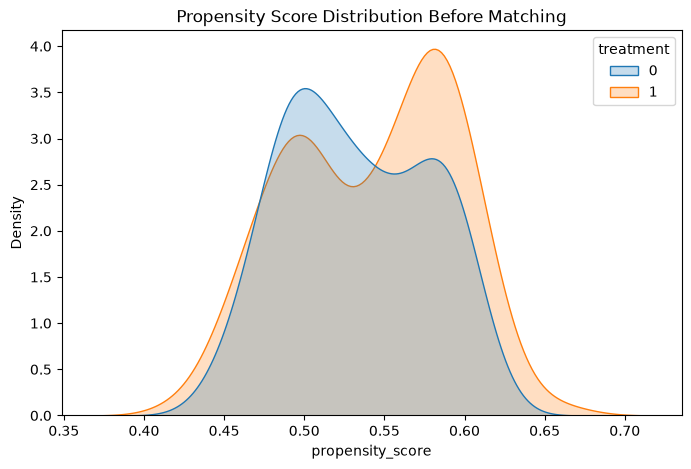

In [8]:
#Visualizing the distribution of propensity scores

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=baseline,
    x="propensity_score",
    hue="treatment",
    fill=True
)

plt.title(
    "Propensity Score Distribution Before Matching"
          )

plt.savefig("../outputs/figures/ps_before_matching.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Interpretation of Propensity Score Distributions

The propensity score distributions for treatment and comparison pupils exhibit substantial overlap, indicating adequate common support between groups.

This suggests that comparable pupils can be identified across treatment and comparison groups based on observed characteristics such as gender, class level, attendance, and study hours.

However, the distributions are not perfectly aligned, indicating that program participation may be associated with observable differences among pupils. These differences may introduce selection bias if not accounted for.

To improve comparability between groups, nearest-neighbor matching will be applied in the next step to construct a matched sample for subsequent impact estimation.

## Perform Matching

## Nearest-Neighbor Matching

Pupils in the treatment group are matched to similar pupils in the comparison group using nearest-neighbor matching based on estimated propensity scores.

In [9]:
treated = baseline[
    baseline["treatment"] == 1
    ].copy()

control = baseline[
    baseline["treatment"] == 0
    ].copy()

In [10]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(
    n_neighbors=1
    )

nn.fit(
    control[["propensity_score"]]
    )

distances, indices = nn.kneighbors(
    treated[["propensity_score"]]
    )

In [11]:
# Created Matched Sample

matched_control = control.iloc[
    indices.flatten()
    ].copy()

In [12]:
matched_sample = pd.concat(
    [treated, matched_control],
    ignore_index=True
    )

matched_sample.head()

,student_id,class_level,gender,treatment,attendance_rate,study_hours,post,time,test_score,female,p6,propensity_score
0,1,P5,Girl,1,92.3,6.6,0,baseline,70.6,1,0,0.615558
1,2,P6,Boy,1,89.8,3.7,0,baseline,76.9,0,1,0.486780
2,3,P5,Girl,1,95.8,10.9,0,baseline,85.0,1,0,0.659923
3,6,P6,Girl,1,85.9,7.5,0,baseline,75.5,1,1,0.585451
4,8,P5,Boy,1,81.0,6.4,0,baseline,74.5,0,0,0.490045


In [ ]:
# Comparing Propensity Score Distributions After Matching

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=matched_sample,
    x="propensity_score",
    hue="treatment",
    fill=True
)

plt.title(
    "Propensity Score Distribution After Matching"
          )

plt.savefig("../outputs/figures/ps_after_matching.png",
            dpi=300,
            bbox_inches="tight")

plt.show()